SOORTELIJKE WARMTE WATER BEPALEN

Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.

Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.

Voer het experiment van een ander team uit op basis van hun beschrijving.

Analyseer de data die het andere groepje voor jou heeft verzameld.



Onze beschrijving voor het uitvoeren van de proef

Doe 500 g water in de maatbeker nadat je deze hebt getarreerd op de weegschaal; doe het roerstaafje in de maatbeker en zet de maatbeker op de roerplaat, zet vervolgens de roerplaat aan zodat het staafje het water wordt geroerd; doe het warmte-element en de thermometer in de maatbeker; zet de thermometer aan en sluit het warmte-element aan op de maatbeker; sluit vervolgens de voltmeter aan over de power supply; stel de power supply zo in dat de voltmeter 20 V aangeeft; doe de nulmeting voordat het warmte-element aanstaat; zet deze vervolgens aan, start de timer de doe de eerste meting na een halve minuut; doe vervolgens elke halve minuut een meting voor 10 minuten; dat zijn dus 21 metingen incl. nulmeting in totaal. 



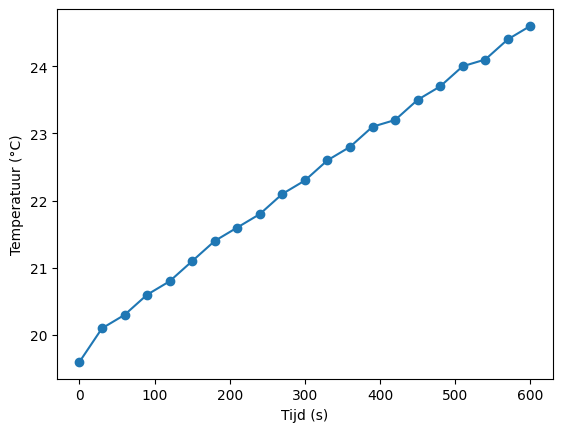

In [1]:
#data analyse practicum verdamping

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.genfromtxt(r'C:\Users\caspe\Werkruimte\Documents\Studie\Technische_natuurkunde\IP_2\RawData_cWater.csv', delimiter=';', skip_header=1)

tijd = data[:, 0]  # tijd in seconden
temperatuur = data[:, 1]  # verdamping in mm

plt.figure()
plt.plot(tijd, temperatuur, marker='o', linestyle='-')
plt.xlabel('Tijd (s)')
plt.ylabel('Temperatuur (°C)')
plt.show()


theorie: Q = m * c * deltaT; P = U**2 / R; Q = P * t

Er is gebruik gemaakt van een 10 ohm weerstand op 20 V, dus een P van P = 20**2 / 10 = 40 W. Vervolgens is Q gelijk aan Q = 40 * 600 = 24000 J; 600 want er is gedurende 600 s gemeten, ofwel de tijd tussen T1 en T2. De soortelijke warmte van water kan bereken worden met: c = Q / (m * deltaT). Het opgewarmde water heeft een massa van 500 g. 


In [ ]:
Q = 24000  # J
m = 0.5 #kg
c_water = Q / (m * (temperatuur[-1] - temperatuur[0]))
print(f'Soortelijke warmte van water: {c_water} J/(kg·°C)')



Soortelijke warmte van water: 9600.0 J/(kg·°C)
24.6
19.6


Onze berekende c_water is 9600.0 J/(kg·°C), de literatuur waarde is 4186 J/(kg·°C). Mogelijke redenen voor dit verschil is dat er gedurende meting warmte verliezen zijn naar de omgeving, in de berekening wordt er namelijk vanuit gegaan dat alle elektrische energie wordt omgezet in de opwarming van het water. 

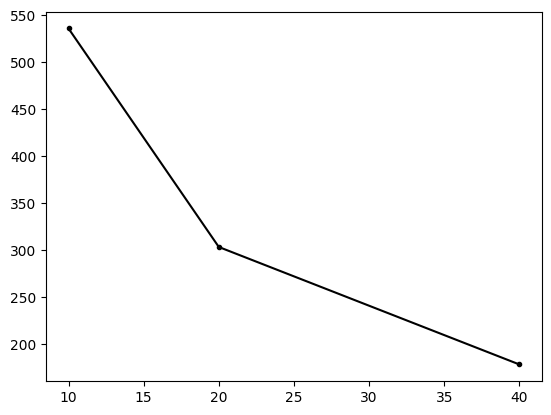

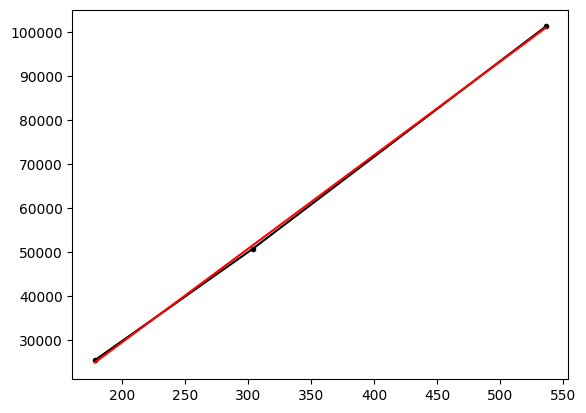

In [19]:
volume = [10,20,40]  # in ml
output = [536, 303.5, 178.5]
output2 = [435.5, 285.5, 177.5]

plt.figure()
plt.plot(volume, output,'k.', linestyle='-')
plt.show()

P1 = 1.01325 * 1e5  # Pa
P2 = (P1 * volume[0])/volume[1]
P3 = (P1 * volume[0])/volume[2]

druk = [P1, P2, P3]


plt.figure()
plt.plot(output, druk, 'k.', linestyle='-')


def functiefit(x, a, b):
    return a * x + b


var, cov = curve_fit(functiefit, output, druk)

plt.plot(output, functiefit(np.array(output), var[0], var[1]), label='fit', color='red')
plt.show()